In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [9]:
# ============================================================================
# CELL 2: Load Raw Data
# ============================================================================
# Load the two CSV files from the unclean_data folder
retail_rice_df = pd.read_csv('../unclean_data/Retail_USA_RICE.csv')
food_cpi_df = pd.read_csv('../unclean_data/CPI_USA_RICE.csv')

print("RAW DATA LOADED")
print(f"\n1. Retail Rice Prices:")
print(f"   Shape: {retail_rice_df.shape}")
print(f"   Columns: {list(retail_rice_df.columns)}")
print(f"   Date Range: {retail_rice_df['observation_date'].min()} to {retail_rice_df['observation_date'].max()}")
print(f"\n   First 5 rows:")
print(retail_rice_df.head())

print(f"\n2. Food CPI:")
print(f"   Shape: {food_cpi_df.shape}")
print(f"   Columns: {list(food_cpi_df.columns)}")
print(f"   Date Range: {food_cpi_df['observation_date'].min()} to {food_cpi_df['observation_date'].max()}")
print(f"\n   First 5 rows:")
print(food_cpi_df.head())

RAW DATA LOADED

1. Retail Rice Prices:
   Shape: (549, 2)
   Columns: ['observation_date', 'APU0000701312']
   Date Range: 1980-01-01 to 2025-09-01

   First 5 rows:
  observation_date  APU0000701312
0       1980-01-01          0.484
1       1980-02-01          0.488
2       1980-03-01          0.489
3       1980-04-01          0.511
4       1980-05-01          0.510

2. Food CPI:
   Shape: (1353, 2)
   Columns: ['observation_date', 'CPIUFDNS']
   Date Range: 1913-01-01 to 2025-09-01

   First 5 rows:
  observation_date  CPIUFDNS
0       1913-01-01       9.7
1       1913-02-01       9.6
2       1913-03-01       9.6
3       1913-04-01       9.7
4       1913-05-01       9.6


In [10]:
print("INITIAL DATA EXPLORATION")

print("\n1. Rice Prices - Data Info:")
print(retail_rice_df.info())

print("\n2. Food CPI - Data Info:")
print(food_cpi_df.info())

print("\n3. Missing Values Check:")
print(f"   Rice prices missing: {retail_rice_df.isnull().sum().sum()}")
print(f"   Food CPI missing: {food_cpi_df.isnull().sum().sum()}")

print("\n4. Basic Statistics - Rice Prices:")
print(retail_rice_df.describe())

print("\n5. Basic Statistics - Food CPI:")
print(food_cpi_df.describe())

INITIAL DATA EXPLORATION

1. Rice Prices - Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  549 non-null    object 
 1   APU0000701312     524 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.7+ KB
None

2. Food CPI - Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  1353 non-null   object 
 1   CPIUFDNS          1353 non-null   float64
dtypes: float64(1), object(1)
memory usage: 21.3+ KB
None

3. Missing Values Check:
   Rice prices missing: 25
   Food CPI missing: 0

4. Basic Statistics - Rice Prices:
       APU0000701312
count     524.000000
mean        0.622191
std         0.159041
min         0.391000
25

In [11]:
print("DATA CLEANING: DATES AND COLUMN NAMES")

# Convert observation_date to datetime
retail_rice_df['date'] = pd.to_datetime(retail_rice_df['observation_date'])
food_cpi_df['date'] = pd.to_datetime(food_cpi_df['observation_date'])

# Rename columns for clarity
retail_rice_df = retail_rice_df.rename(columns={
    'APU0000701312': 'price_usd_per_lb',
    'observation_date': 'date_str'
})

food_cpi_df = food_cpi_df.rename(columns={
    'CPIUFDNS': 'food_cpi_index',
    'observation_date': 'date_str'
})

print("✓ Dates converted to datetime format")
print("✓ Columns renamed for clarity")
print(f"\nRice columns: {list(retail_rice_df.columns)}")
print(f"CPI columns: {list(food_cpi_df.columns)}")

DATA CLEANING: DATES AND COLUMN NAMES
✓ Dates converted to datetime format
✓ Columns renamed for clarity

Rice columns: ['date_str', 'price_usd_per_lb', 'date']
CPI columns: ['date_str', 'food_cpi_index', 'date']


In [12]:
print("FILTERING TO PROJECT TIMEFRAME (2017-2024)")

# Define project timeframe
start_date = '2017-01-01'
end_date = '2024-12-31'

# Filter both datasets
retail_rice_clean = retail_rice_df[
    (retail_rice_df['date'] >= start_date) & 
    (retail_rice_df['date'] <= end_date)
].copy()

food_cpi_clean = food_cpi_df[
    (food_cpi_df['date'] >= start_date) & 
    (food_cpi_df['date'] <= end_date)
].copy()

print(f"Date range: {start_date} to {end_date}")
print(f"\nBefore filtering:")
print(f"  Rice: {len(retail_rice_df)} observations")
print(f"  CPI: {len(food_cpi_df)} observations")

print(f"\nAfter filtering:")
print(f"  Rice: {len(retail_rice_clean)} observations")
print(f"  CPI: {len(food_cpi_clean)} observations")

print(f"\nFiltered to {len(retail_rice_clean)} months of data")

FILTERING TO PROJECT TIMEFRAME (2017-2024)
Date range: 2017-01-01 to 2024-12-31

Before filtering:
  Rice: 549 observations
  CPI: 1353 observations

After filtering:
  Rice: 96 observations
  CPI: 96 observations

Filtered to 96 months of data


In [13]:
print("="*80)
print("UNIT CONVERSION: USD/LB → USD/KG")
print("="*80)

# Convert USD per pound to USD per kilogram
# 1 kg = 2.20462 pounds
retail_rice_clean['price_usd_per_kg'] = retail_rice_clean['price_usd_per_lb'] * 2.20462

print("Conversion factor: 1 kg = 2.20462 lbs")
print("\nExample conversions:")
for i in range(3):
    lb_price = retail_rice_clean.iloc[i]['price_usd_per_lb']
    kg_price = retail_rice_clean.iloc[i]['price_usd_per_kg']
    date = retail_rice_clean.iloc[i]['date'].strftime('%Y-%m-%d')
    print(f"  {date}: ${lb_price:.3f}/lb = ${kg_price:.3f}/kg")

print("\n✓ Unit conversion complete")

UNIT CONVERSION: USD/LB → USD/KG
Conversion factor: 1 kg = 2.20462 lbs

Example conversions:
  2017-01-01: $0.700/lb = $1.543/kg
  2017-02-01: $0.695/lb = $1.532/kg
  2017-03-01: $0.692/lb = $1.526/kg

✓ Unit conversion complete


In [14]:
print("="*80)
print("EXTRACTING TIME FEATURES")
print("="*80)

# Extract year, month, and year-month for both datasets
for df, name in [(retail_rice_clean, 'Rice'), (food_cpi_clean, 'CPI')]:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['month_name'] = df['date'].dt.month_name()
    df['year_month'] = df['date'].dt.to_period('M')
    df['quarter'] = df['date'].dt.quarter
    print(f"✓ Time features extracted for {name} data")

print("\nAvailable time columns:")
print(f"  year, month, month_name, year_month, quarter")

print(f"\nSample of time features:")
print(retail_rice_clean[['date', 'year', 'month', 'month_name', 'quarter']].head())

EXTRACTING TIME FEATURES
✓ Time features extracted for Rice data
✓ Time features extracted for CPI data

Available time columns:
  year, month, month_name, year_month, quarter

Sample of time features:
          date  year  month month_name  quarter
444 2017-01-01  2017      1    January        1
445 2017-02-01  2017      2   February        1
446 2017-03-01  2017      3      March        1
447 2017-04-01  2017      4      April        2
448 2017-05-01  2017      5        May        2


In [15]:
print("="*80)
print("FEATURE ENGINEERING: YEAR-OVER-YEAR CHANGES")
print("="*80)

# Sort by date to ensure proper time series calculation
retail_rice_clean = retail_rice_clean.sort_values('date').reset_index(drop=True)
food_cpi_clean = food_cpi_clean.sort_values('date').reset_index(drop=True)

# Calculate YoY percentage change (comparing to same month last year)
retail_rice_clean['price_yoy_pct'] = retail_rice_clean['price_usd_per_kg'].pct_change(periods=12) * 100
retail_rice_clean['price_yoy_absolute'] = retail_rice_clean['price_usd_per_kg'].diff(periods=12)

food_cpi_clean['cpi_yoy_pct'] = food_cpi_clean['food_cpi_index'].pct_change(periods=12) * 100
food_cpi_clean['cpi_yoy_absolute'] = food_cpi_clean['food_cpi_index'].diff(periods=12)

print("✓ Year-over-year changes calculated (12-month lag)")
print("\nYoY Change Examples (first non-null values):")
yoy_sample = retail_rice_clean[retail_rice_clean['price_yoy_pct'].notna()].head(3)
for _, row in yoy_sample.iterrows():
    print(f"  {row['date'].strftime('%Y-%m')}: {row['price_yoy_pct']:+.2f}% (${row['price_yoy_absolute']:+.3f}/kg)")



FEATURE ENGINEERING: YEAR-OVER-YEAR CHANGES
✓ Year-over-year changes calculated (12-month lag)

YoY Change Examples (first non-null values):
  2018-01: -2.57% ($-0.040/kg)
  2018-02: -0.58% ($-0.009/kg)
  2018-03: -1.45% ($-0.022/kg)


In [16]:
print("="*80)
print("FEATURE ENGINEERING: BASELINE INDEX (2017 = 100)")
print("="*80)

# Calculate 2017 average as baseline
baseline_rice = retail_rice_clean[retail_rice_clean['year'] == 2017]['price_usd_per_kg'].mean()
baseline_cpi = food_cpi_clean[food_cpi_clean['year'] == 2017]['food_cpi_index'].mean()

# Create index with 2017 = 100
retail_rice_clean['price_index_2017'] = (retail_rice_clean['price_usd_per_kg'] / baseline_rice) * 100
food_cpi_clean['cpi_index_2017'] = (food_cpi_clean['food_cpi_index'] / baseline_cpi) * 100

print(f"Baseline values (2017 average):")
print(f"  Rice price: ${baseline_rice:.3f}/kg")
print(f"  Food CPI: {baseline_cpi:.2f}")

print(f"\n2017 Index = 100")
print(f"2024 Rice Index: {retail_rice_clean[retail_rice_clean['year']==2024]['price_index_2017'].mean():.2f}")
print(f"2024 CPI Index: {food_cpi_clean[food_cpi_clean['year']==2024]['cpi_index_2017'].mean():.2f}")

print("\n✓ Baseline indices created")

FEATURE ENGINEERING: BASELINE INDEX (2017 = 100)
Baseline values (2017 average):
  Rice price: $1.590/kg
  Food CPI: 250.06

2017 Index = 100
2024 Rice Index: 143.40
2024 CPI Index: 132.07

✓ Baseline indices created


In [17]:
print("="*80)
print("MERGING RICE AND CPI DATASETS")
print("="*80)

# Select relevant columns for merge
rice_cols = ['date', 'year', 'month', 'month_name', 'quarter', 'year_month',
             'price_usd_per_lb', 'price_usd_per_kg', 
             'price_yoy_pct', 'price_yoy_absolute', 'price_index_2017']

cpi_cols = ['date', 'food_cpi_index', 
            'cpi_yoy_pct', 'cpi_yoy_absolute', 'cpi_index_2017']

# Merge on date
merged_df = pd.merge(
    retail_rice_clean[rice_cols],
    food_cpi_clean[cpi_cols],
    on='date',
    how='inner'
)

print(f"Merged dataset shape: {merged_df.shape}")
print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")
print(f"\nColumns in merged dataset:")
for i, col in enumerate(merged_df.columns, 1):
    print(f"  {i}. {col}")

print("\n✓ Datasets successfully merged")
print(f"\nFirst 5 rows of merged data:")
print(merged_df.head())

MERGING RICE AND CPI DATASETS
Merged dataset shape: (96, 15)
Date range: 2017-01-01 00:00:00 to 2024-12-01 00:00:00

Columns in merged dataset:
  1. date
  2. year
  3. month
  4. month_name
  5. quarter
  6. year_month
  7. price_usd_per_lb
  8. price_usd_per_kg
  9. price_yoy_pct
  10. price_yoy_absolute
  11. price_index_2017
  12. food_cpi_index
  13. cpi_yoy_pct
  14. cpi_yoy_absolute
  15. cpi_index_2017

✓ Datasets successfully merged

First 5 rows of merged data:
        date  year  month month_name  quarter year_month  price_usd_per_lb  \
0 2017-01-01  2017      1    January        1    2017-01             0.700   
1 2017-02-01  2017      2   February        1    2017-02             0.695   
2 2017-03-01  2017      3      March        1    2017-03             0.692   
3 2017-04-01  2017      4      April        2    2017-04             0.686   
4 2017-05-01  2017      5        May        2    2017-05             0.726   

   price_usd_per_kg  price_yoy_pct  price_yoy_absolute 

In [18]:
print("="*80)
print("FEATURE ENGINEERING: RICE AFFORDABILITY INDEX")
print("="*80)

# Calculate affordability index
# Lower values = rice is MORE affordable relative to general food prices
# Higher values = rice is LESS affordable relative to general food prices
merged_df['affordability_index'] = (merged_df['price_index_2017'] / merged_df['cpi_index_2017']) * 100

print("Affordability Index Formula:")
print("  (Rice Price Index ÷ Food CPI Index) × 100")
print("\nInterpretation:")
print("  • Index > 100: Rice prices growing FASTER than food inflation (less affordable)")
print("  • Index = 100: Rice prices tracking with food inflation")
print("  • Index < 100: Rice prices growing SLOWER than food inflation (more affordable)")

print(f"\nAffordability Index Summary:")
print(merged_df['affordability_index'].describe())

print(f"\nMost affordable period: {merged_df.loc[merged_df['affordability_index'].idxmin(), 'date'].strftime('%Y-%m')} "
      f"(Index: {merged_df['affordability_index'].min():.2f})")
print(f"Least affordable period: {merged_df.loc[merged_df['affordability_index'].idxmax(), 'date'].strftime('%Y-%m')} "
      f"(Index: {merged_df['affordability_index'].max():.2f})")

print("\n✓ Affordability index calculated")

FEATURE ENGINEERING: RICE AFFORDABILITY INDEX
Affordability Index Formula:
  (Rice Price Index ÷ Food CPI Index) × 100

Interpretation:
  • Index > 100: Rice prices growing FASTER than food inflation (less affordable)
  • Index = 100: Rice prices tracking with food inflation
  • Index < 100: Rice prices growing SLOWER than food inflation (more affordable)

Affordability Index Summary:
count     95.000000
mean     101.633888
std        4.857788
min       93.371021
25%       97.431567
50%      101.924774
75%      105.738736
max      113.735705
Name: affordability_index, dtype: float64

Most affordable period: 2018-10 (Index: 93.37)
Least affordable period: 2024-08 (Index: 113.74)

✓ Affordability index calculated


In [19]:
print("="*80)
print("DATA QUALITY VALIDATION")
print("="*80)

print("1. Missing Values:")
print(merged_df.isnull().sum())

print("\n2. Duplicate Dates:")
print(f"   Total rows: {len(merged_df)}")
print(f"   Unique dates: {merged_df['date'].nunique()}")
print(f"   Duplicates: {len(merged_df) - merged_df['date'].nunique()}")

print("\n3. Data Types:")
print(merged_df.dtypes)

print("\n4. Date Continuity Check:")
date_diff = merged_df['date'].diff()
gaps = date_diff[date_diff > pd.Timedelta(days=35)]
print(f"   Gaps > 35 days: {len(gaps)}")
if len(gaps) > 0:
    print("   Gap locations:", gaps.index.tolist())

print("\n5. Outlier Detection (3 standard deviations):")
for col in ['price_usd_per_kg', 'food_cpi_index']:
    mean = merged_df[col].mean()
    std = merged_df[col].std()
    outliers = merged_df[(merged_df[col] < mean - 3*std) | (merged_df[col] > mean + 3*std)]
    print(f"   {col}: {len(outliers)} outliers")

print("\n✓ Data quality checks complete")

DATA QUALITY VALIDATION
1. Missing Values:
date                    0
year                    0
month                   0
month_name              0
quarter                 0
year_month              0
price_usd_per_lb        1
price_usd_per_kg        1
price_yoy_pct          12
price_yoy_absolute     14
price_index_2017        1
food_cpi_index          0
cpi_yoy_pct            12
cpi_yoy_absolute       12
cpi_index_2017          0
affordability_index     1
dtype: int64

2. Duplicate Dates:
   Total rows: 96
   Unique dates: 96
   Duplicates: 0

3. Data Types:
date                   datetime64[ns]
year                            int32
month                           int32
month_name                     object
quarter                         int32
year_month                  period[M]
price_usd_per_lb              float64
price_usd_per_kg              float64
price_yoy_pct                 float64
price_yoy_absolute            float64
price_index_2017              float64
food_cpi_index    

In [20]:
print("="*80)
print("ANNUAL SUMMARY STATISTICS")
print("="*80)

# Group by year and calculate statistics
annual_summary = merged_df.groupby('year').agg({
    'price_usd_per_kg': ['mean', 'min', 'max', 'std'],
    'food_cpi_index': ['mean', 'min', 'max', 'std'],
    'price_yoy_pct': 'mean',
    'cpi_yoy_pct': 'mean',
    'affordability_index': 'mean'
}).round(3)

annual_summary.columns = ['_'.join(col).strip() for col in annual_summary.columns.values]

print("Annual Summary (2017-2024):")
print(annual_summary)

# Save for later use
print("\n✓ Annual summary calculated")

ANNUAL SUMMARY STATISTICS
Annual Summary (2017-2024):
      price_usd_per_kg_mean  price_usd_per_kg_min  price_usd_per_kg_max  \
year                                                                      
2017                  1.590                 1.512                 1.684   
2018                  1.529                 1.504                 1.570   
2019                  1.685                 1.574                 1.766   
2020                  1.672                 1.579                 1.744   
2021                  1.750                 1.702                 1.861   
2022                  2.013                 1.830                 2.141   
2023                  2.171                 2.114                 2.218   
2024                  2.280                 2.205                 2.392   

      price_usd_per_kg_std  food_cpi_index_mean  food_cpi_index_min  \
year                                                                  
2017                 0.058              250.065      

In [21]:
print("="*80)
print("OVERALL SUMMARY STATISTICS (2017-2024)")
print("="*80)

print("1. RICE PRICES (USD/kg):")
print(merged_df['price_usd_per_kg'].describe())

print("\n2. FOOD CPI INDEX:")
print(merged_df['food_cpi_index'].describe())

print("\n3. KEY METRICS:")
print(f"   • Total observations: {len(merged_df)}")
print(f"   • Time span: {(merged_df['date'].max() - merged_df['date'].min()).days} days")
print(f"   • Years covered: {merged_df['year'].nunique()}")

rice_2017 = merged_df[merged_df['year']==2017]['price_usd_per_kg'].mean()
rice_2024 = merged_df[merged_df['year']==2024]['price_usd_per_kg'].mean()
cpi_2017 = merged_df[merged_df['year']==2017]['food_cpi_index'].mean()
cpi_2024 = merged_df[merged_df['year']==2024]['food_cpi_index'].mean()

print(f"\n4. OVERALL CHANGE (2017 → 2024):")
print(f"   • Rice price: ${rice_2017:.3f} → ${rice_2024:.3f} ({((rice_2024/rice_2017-1)*100):+.1f}%)")
print(f"   • Food CPI: {cpi_2017:.2f} → {cpi_2024:.2f} ({((cpi_2024/cpi_2017-1)*100):+.1f}%)")

print(f"\n5. EXTREME VALUES:")
max_price_row = merged_df.loc[merged_df['price_usd_per_kg'].idxmax()]
min_price_row = merged_df.loc[merged_df['price_usd_per_kg'].idxmin()]
print(f"   • Highest rice price: ${max_price_row['price_usd_per_kg']:.3f}/kg on {max_price_row['date'].strftime('%Y-%m')}")
print(f"   • Lowest rice price: ${min_price_row['price_usd_per_kg']:.3f}/kg on {min_price_row['date'].strftime('%Y-%m')}")

OVERALL SUMMARY STATISTICS (2017-2024)
1. RICE PRICES (USD/kg):
count    95.000000
mean      1.838073
std       0.271433
min       1.503551
25%       1.612680
50%       1.737241
75%       2.123049
max       2.392013
Name: price_usd_per_kg, dtype: float64

2. FOOD CPI INDEX:
count     96.000000
mean     283.191156
std       30.373330
min      248.242000
25%      256.115250
50%      270.480500
75%      317.413250
max      333.566000
Name: food_cpi_index, dtype: float64

3. KEY METRICS:
   • Total observations: 96
   • Time span: 2891 days
   • Years covered: 8

4. OVERALL CHANGE (2017 → 2024):
   • Rice price: $1.590 → $2.280 (+43.4%)
   • Food CPI: 250.06 → 330.26 (+32.1%)

5. EXTREME VALUES:
   • Highest rice price: $2.392/kg on 2024-08
   • Lowest rice price: $1.504/kg on 2018-01


In [23]:
print("="*80)
print("SAVING CLEANED DATASETS")
print("="*80)

# Save individual cleaned datasets to the data folder
retail_rice_clean.to_csv('../data/USA_Rice_Retail_Prices_Cleaned.csv', index=False)
food_cpi_clean.to_csv('../data/USA_Food_CPI_Cleaned.csv', index=False)
merged_df.to_csv('../data/USA_Rice_CPI_Merged.csv', index=False)
annual_summary.to_csv('../data/USA_Rice_CPI_Annual_Summary.csv')

print("✓ Saved files to ../data/ folder:")
print("  1. USA_Rice_Retail_Prices_Cleaned.csv")
print("  2. USA_Food_CPI_Cleaned.csv")
print("  3. USA_Rice_CPI_Merged.csv")
print("  4. USA_Rice_CPI_Annual_Summary.csv")

print(f"\nFiles saved to: ../data/")

SAVING CLEANED DATASETS
✓ Saved files to ../data/ folder:
  1. USA_Rice_Retail_Prices_Cleaned.csv
  2. USA_Food_CPI_Cleaned.csv
  3. USA_Rice_CPI_Merged.csv
  4. USA_Rice_CPI_Annual_Summary.csv

Files saved to: ../data/


In [ ]:
#EDA

EDA VISUALIZATION 1: TIME SERIES


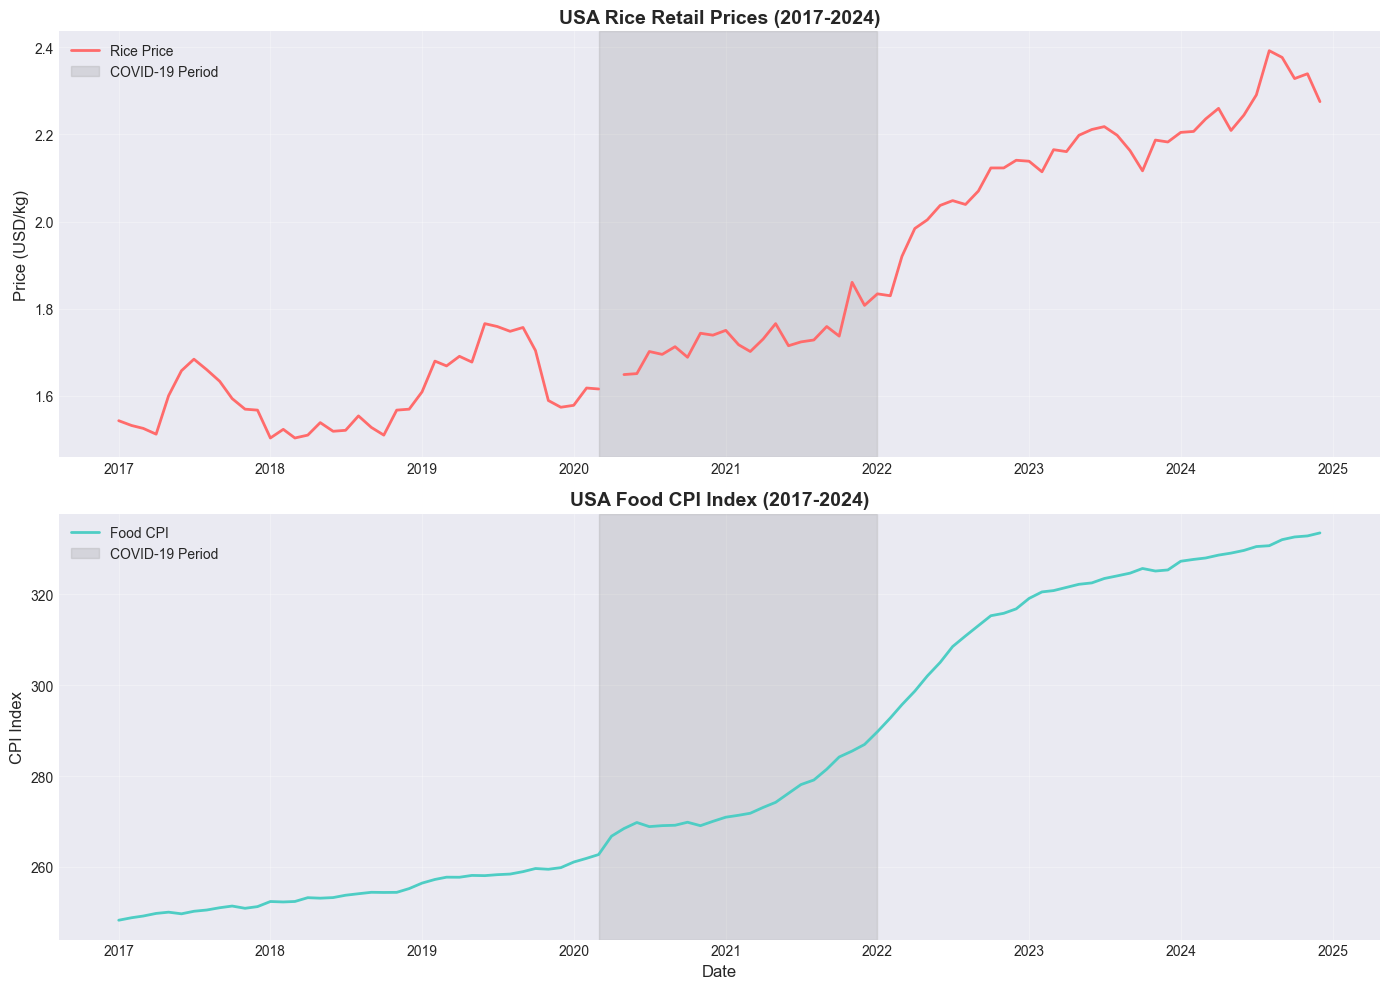

✓ Time series plot created


In [24]:
print("="*80)
print("EDA VISUALIZATION 1: TIME SERIES")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Rice Prices
axes[0].plot(merged_df['date'], merged_df['price_usd_per_kg'], 
             color='#FF6B6B', linewidth=2, label='Rice Price')
axes[0].axvspan('2020-03-01', '2021-12-31', alpha=0.2, color='gray', label='COVID-19 Period')
axes[0].set_title('USA Rice Retail Prices (2017-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD/kg)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Food CPI
axes[1].plot(merged_df['date'], merged_df['food_cpi_index'], 
             color='#4ECDC4', linewidth=2, label='Food CPI')
axes[1].axvspan('2020-03-01', '2021-12-31', alpha=0.2, color='gray', label='COVID-19 Period')
axes[1].set_title('USA Food CPI Index (2017-2024)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('CPI Index', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('USA_Rice_CPI_Timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Time series plot created")

EDA VISUALIZATION 2: DUAL AXIS TIME SERIES


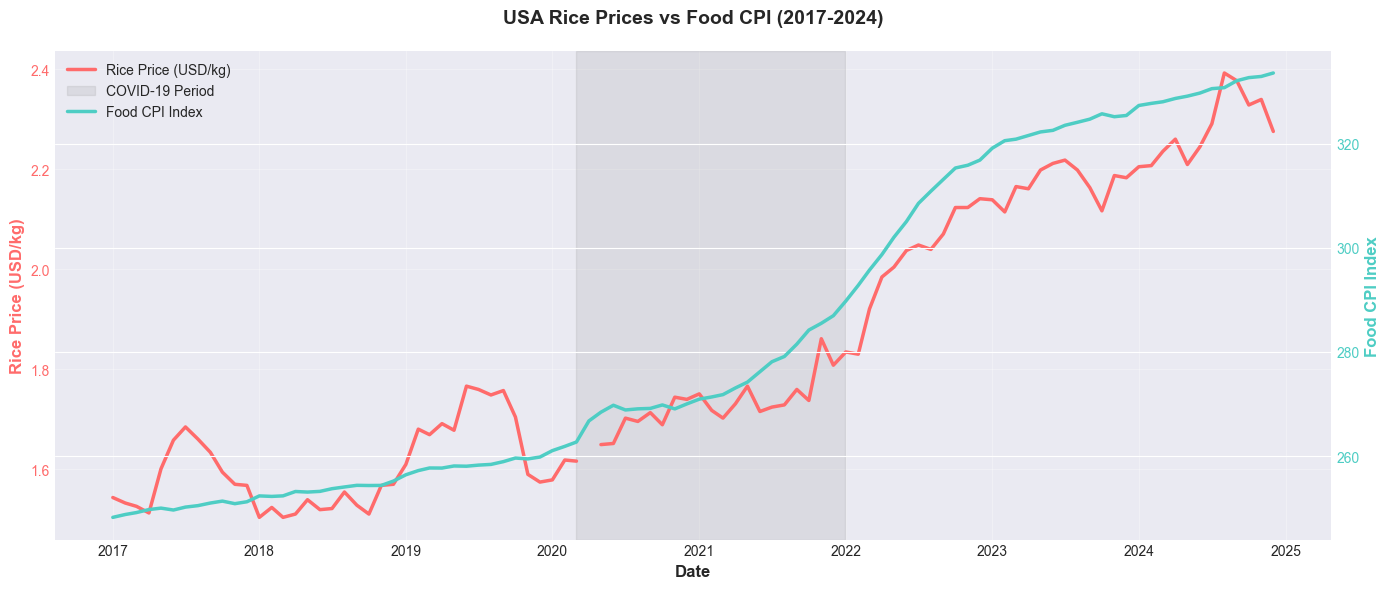

✓ Dual axis plot created


In [25]:
print("="*80)
print("EDA VISUALIZATION 2: DUAL AXIS TIME SERIES")
print("="*80)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Primary y-axis: Rice Prices
ax1.plot(merged_df['date'], merged_df['price_usd_per_kg'], 
         color='#FF6B6B', linewidth=2.5, label='Rice Price (USD/kg)')
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rice Price (USD/kg)', color='#FF6B6B', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#FF6B6B')
ax1.grid(True, alpha=0.3)

# Secondary y-axis: Food CPI
ax2 = ax1.twinx()
ax2.plot(merged_df['date'], merged_df['food_cpi_index'], 
         color='#4ECDC4', linewidth=2.5, label='Food CPI Index')
ax2.set_ylabel('Food CPI Index', color='#4ECDC4', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#4ECDC4')

# Add COVID-19 shading
ax1.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.15, color='gray', label='COVID-19 Period')

# Title and legends
plt.title('USA Rice Prices vs Food CPI (2017-2024)', fontsize=14, fontweight='bold', pad=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('USA_Rice_CPI_DualAxis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dual axis plot created")

EDA VISUALIZATION 3: INDEXED COMPARISON


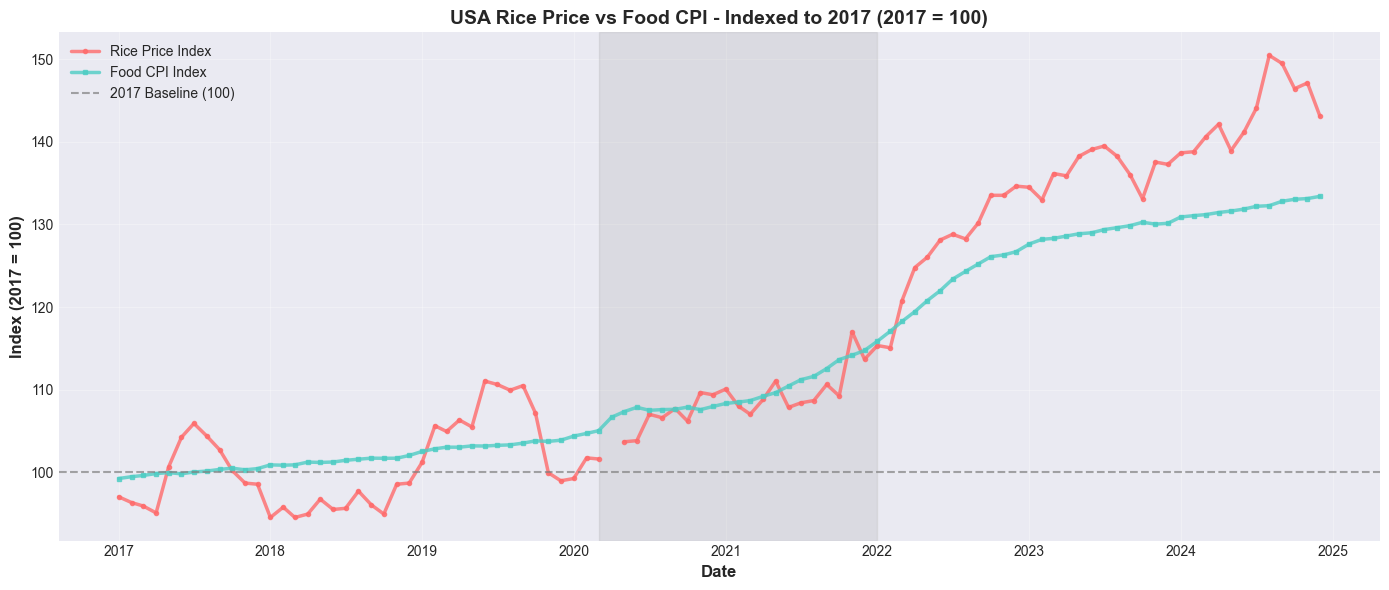

✓ Indexed comparison plot created


In [26]:
print("="*80)
print("EDA VISUALIZATION 3: INDEXED COMPARISON")
print("="*80)

plt.figure(figsize=(14, 6))

plt.plot(merged_df['date'], merged_df['price_index_2017'], 
         color='#FF6B6B', linewidth=2.5, marker='o', markersize=3, 
         label='Rice Price Index', alpha=0.8)
plt.plot(merged_df['date'], merged_df['cpi_index_2017'], 
         color='#4ECDC4', linewidth=2.5, marker='s', markersize=3, 
         label='Food CPI Index', alpha=0.8)

# Add baseline reference line
plt.axhline(y=100, color='gray', linestyle='--', linewidth=1.5, 
            label='2017 Baseline (100)', alpha=0.7)

# Add COVID-19 shading
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.15, color='gray')

plt.title('USA Rice Price vs Food CPI - Indexed to 2017 (2017 = 100)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Index (2017 = 100)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('USA_Rice_CPI_Indexed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Indexed comparison plot created")

EDA VISUALIZATION 4: YOY % CHANGES


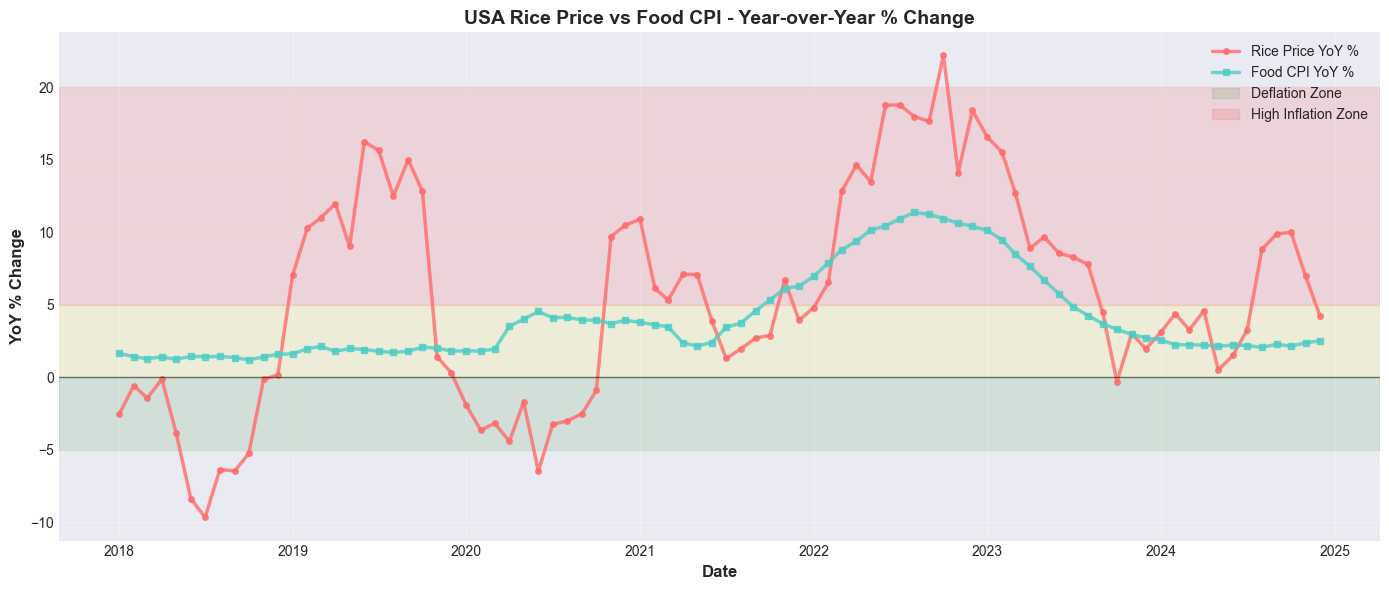

✓ YoY change plot created


In [27]:
print("="*80)
print("EDA VISUALIZATION 4: YOY % CHANGES")
print("="*80)

# Filter out NaN values
yoy_data = merged_df[merged_df['price_yoy_pct'].notna()].copy()

plt.figure(figsize=(14, 6))

plt.plot(yoy_data['date'], yoy_data['price_yoy_pct'], 
         color='#FF6B6B', linewidth=2.5, marker='o', markersize=4,
         label='Rice Price YoY %', alpha=0.8)
plt.plot(yoy_data['date'], yoy_data['cpi_yoy_pct'], 
         color='#4ECDC4', linewidth=2.5, marker='s', markersize=4,
         label='Food CPI YoY %', alpha=0.8)

# Add zero reference line
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Shade areas of high inflation
plt.axhspan(-5, 0, alpha=0.1, color='green', label='Deflation Zone')
plt.axhspan(0, 5, alpha=0.1, color='yellow')
plt.axhspan(5, 20, alpha=0.1, color='red', label='High Inflation Zone')

plt.title('USA Rice Price vs Food CPI - Year-over-Year % Change', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('YoY % Change', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('USA_Rice_CPI_YoY_Change.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ YoY change plot created")


EDA VISUALIZATION 5: AFFORDABILITY INDEX


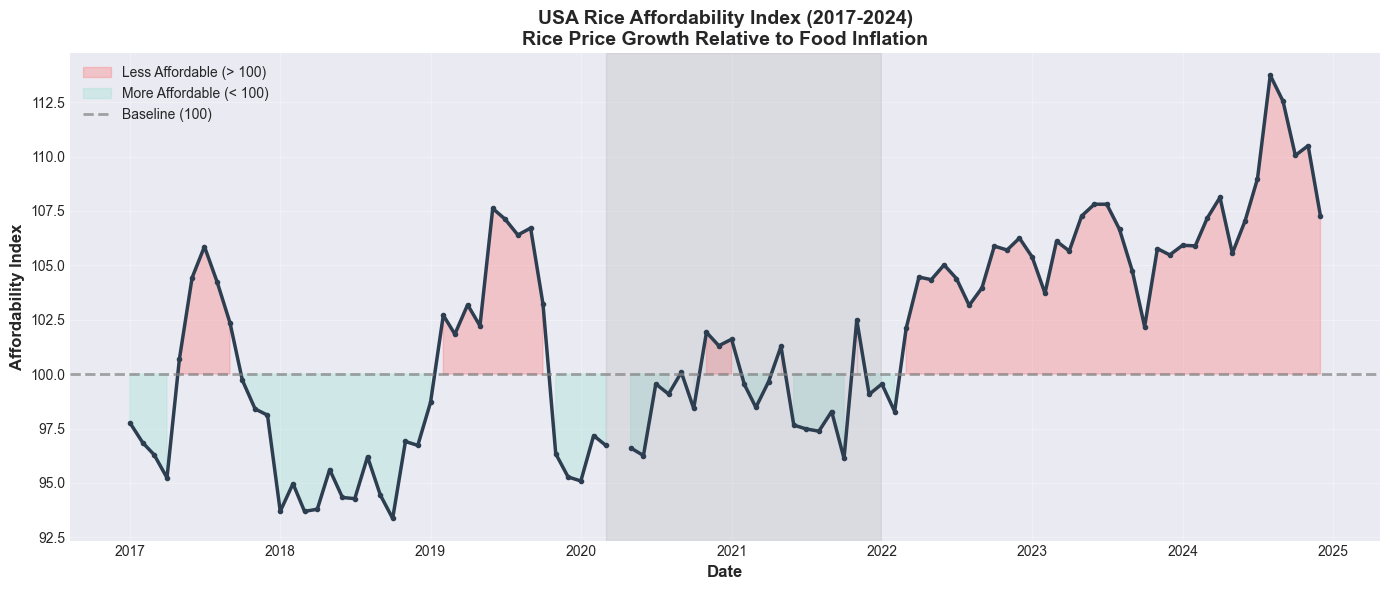

✓ Affordability index plot created


In [28]:
print("="*80)
print("EDA VISUALIZATION 5: AFFORDABILITY INDEX")
print("="*80)

plt.figure(figsize=(14, 6))

# Plot affordability index
plt.fill_between(merged_df['date'], merged_df['affordability_index'], 
                 100, where=(merged_df['affordability_index'] >= 100),
                 color='#FF6B6B', alpha=0.3, label='Less Affordable (> 100)')
plt.fill_between(merged_df['date'], merged_df['affordability_index'], 
                 100, where=(merged_df['affordability_index'] < 100),
                 color='#95E1D3', alpha=0.3, label='More Affordable (< 100)')

plt.plot(merged_df['date'], merged_df['affordability_index'], 
         color='#2C3E50', linewidth=2.5, marker='o', markersize=3)

# Add baseline reference
plt.axhline(y=100, color='gray', linestyle='--', linewidth=2, 
            label='Baseline (100)', alpha=0.7)

# Add COVID-19 period
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.15, color='gray')

plt.title('USA Rice Affordability Index (2017-2024)\nRice Price Growth Relative to Food Inflation', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Affordability Index', fontsize=12, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('USA_Rice_Affordability_Index.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Affordability index plot created")

EDA VISUALIZATION 6: ANNUAL COMPARISONS


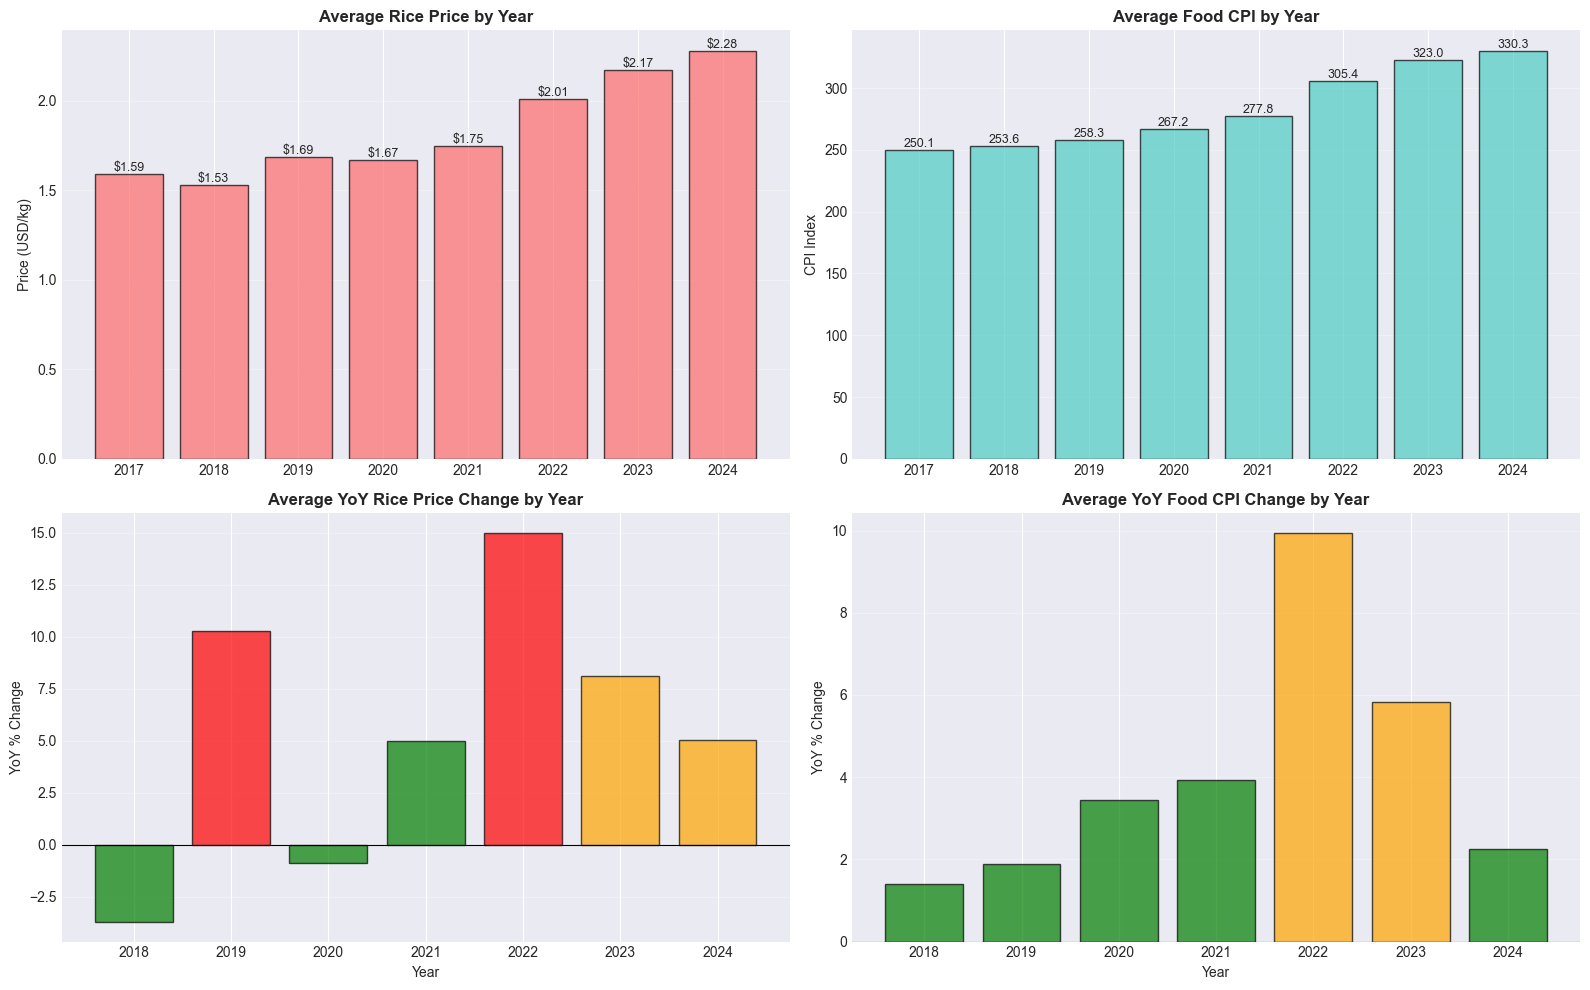

✓ Annual comparison charts created


In [30]:
print("="*80)
print("EDA VISUALIZATION 6: ANNUAL COMPARISONS")
print("="*80)

annual_avg = merged_df.groupby('year').agg({
    'price_usd_per_kg': 'mean',
    'food_cpi_index': 'mean',
    'price_yoy_pct': 'mean',
    'cpi_yoy_pct': 'mean'
}).round(3)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Average Rice Prices by Year
axes[0,0].bar(annual_avg.index, annual_avg['price_usd_per_kg'], 
              color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Average Rice Price by Year', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Price (USD/kg)', fontsize=10)
axes[0,0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(annual_avg['price_usd_per_kg']):
    axes[0,0].text(annual_avg.index[i], v, f'${v:.2f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 2: Average Food CPI by Year
axes[0,1].bar(annual_avg.index, annual_avg['food_cpi_index'], 
              color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Average Food CPI by Year', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('CPI Index', fontsize=10)
axes[0,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(annual_avg['food_cpi_index']):
    axes[0,1].text(annual_avg.index[i], v, f'{v:.1f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 3: YoY Rice Price Change by Year
colors_rice = ['green' if x < 5 else 'orange' if x < 10 else 'red' 
               for x in annual_avg['price_yoy_pct'].fillna(0)]
axes[1,0].bar(annual_avg.index, annual_avg['price_yoy_pct'], 
              color=colors_rice, alpha=0.7, edgecolor='black')
axes[1,0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1,0].set_title('Average YoY Rice Price Change by Year', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('YoY % Change', fontsize=10)
axes[1,0].set_xlabel('Year', fontsize=10)
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: YoY CPI Change by Year
colors_cpi = ['green' if x < 5 else 'orange' if x < 10 else 'red' 
              for x in annual_avg['cpi_yoy_pct'].fillna(0)]
axes[1,1].bar(annual_avg.index, annual_avg['cpi_yoy_pct'], 
              color=colors_cpi, alpha=0.7, edgecolor='black')
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1,1].set_title('Average YoY Food CPI Change by Year', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('YoY % Change', fontsize=10)
axes[1,1].set_xlabel('Year', fontsize=10)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('USA_Rice_CPI_Annual_Charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Annual comparison charts created")

EDA VISUALIZATION 7: SEASONAL PATTERNS


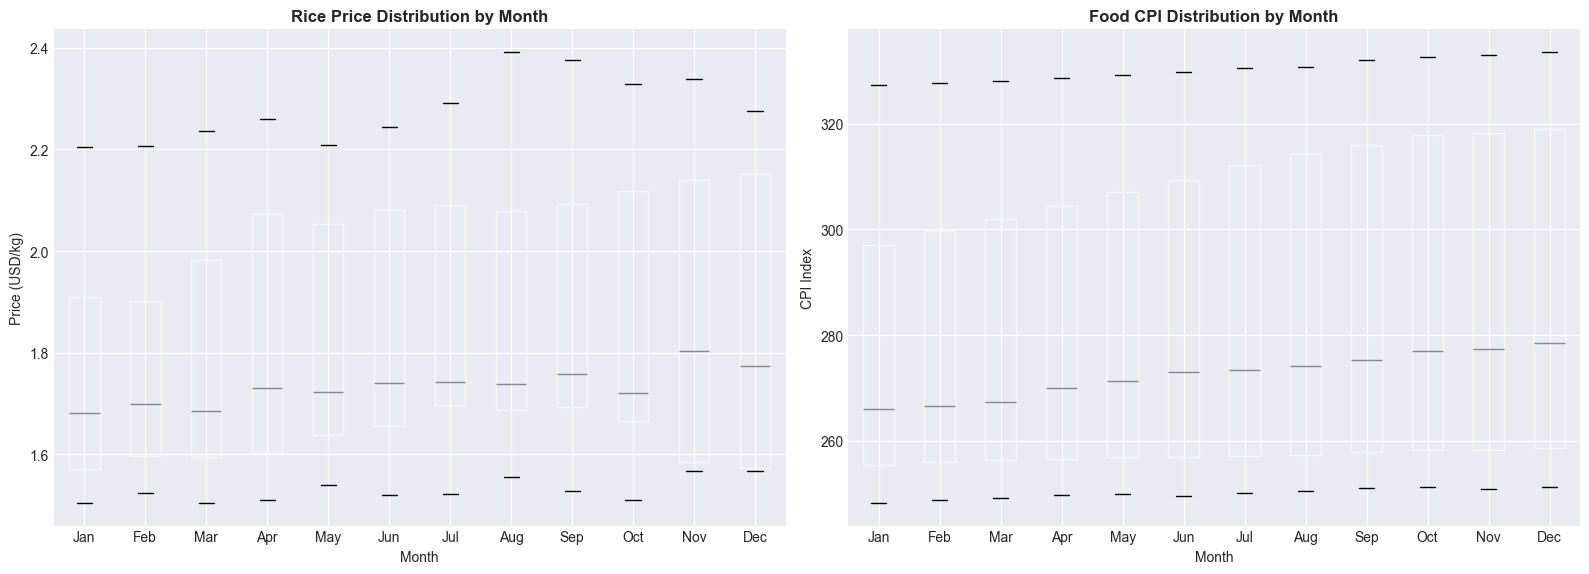

✓ Seasonal pattern plots created


In [31]:
print("="*80)
print("EDA VISUALIZATION 7: SEASONAL PATTERNS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot 1: Rice prices by month
merged_df.boxplot(column='price_usd_per_kg', by='month', ax=axes[0])
axes[0].set_title('Rice Price Distribution by Month', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=10)
axes[0].set_ylabel('Price (USD/kg)', fontsize=10)
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Boxplot 2: Food CPI by month
merged_df.boxplot(column='food_cpi_index', by='month', ax=axes[1])
axes[1].set_title('Food CPI Distribution by Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=10)
axes[1].set_ylabel('CPI Index', fontsize=10)
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig('USA_Rice_CPI_Seasonal_Patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Seasonal pattern plots created")

EDA VISUALIZATION 8: CORRELATION ANALYSIS


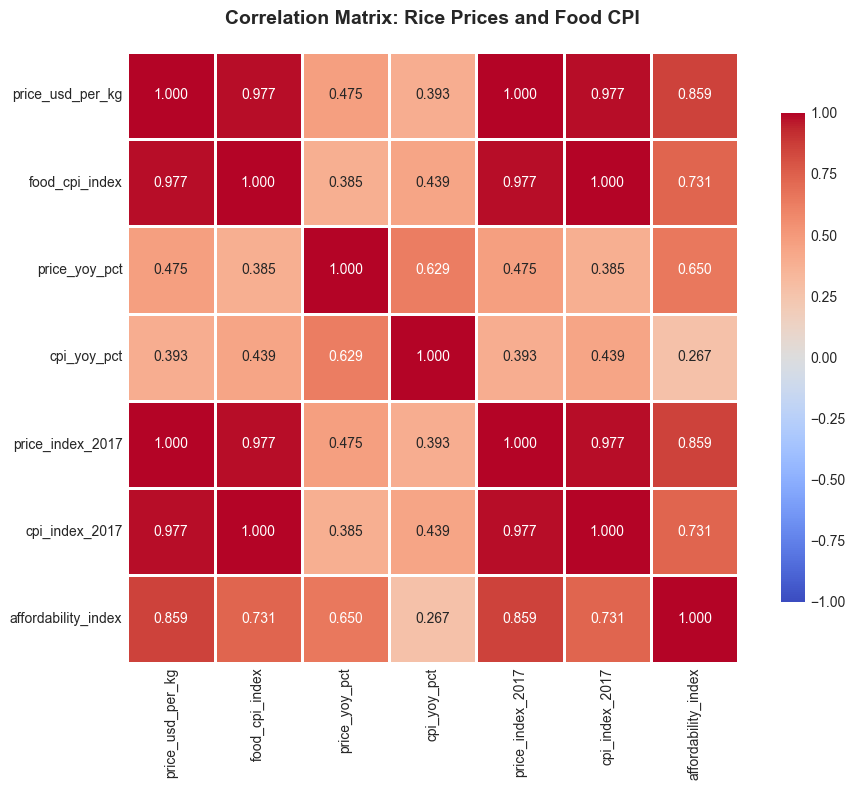

✓ Correlation heatmap created

Key Correlations:
price_usd_per_kg       1.000000
price_index_2017       1.000000
cpi_index_2017         0.976678
food_cpi_index         0.976678
affordability_index    0.859337
price_yoy_pct          0.474928
cpi_yoy_pct            0.392882
Name: price_usd_per_kg, dtype: float64


In [32]:
print("="*80)
print("EDA VISUALIZATION 8: CORRELATION ANALYSIS")
print("="*80)

# Select numerical columns for correlation
corr_cols = ['price_usd_per_kg', 'food_cpi_index', 'price_yoy_pct', 
             'cpi_yoy_pct', 'price_index_2017', 'cpi_index_2017', 
             'affordability_index']

correlation_matrix = merged_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Rice Prices and Food CPI', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('USA_Rice_CPI_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap created")
print("\nKey Correlations:")
print(correlation_matrix['price_usd_per_kg'].sort_values(ascending=False))

EDA VISUALIZATION 9: DISTRIBUTIONS


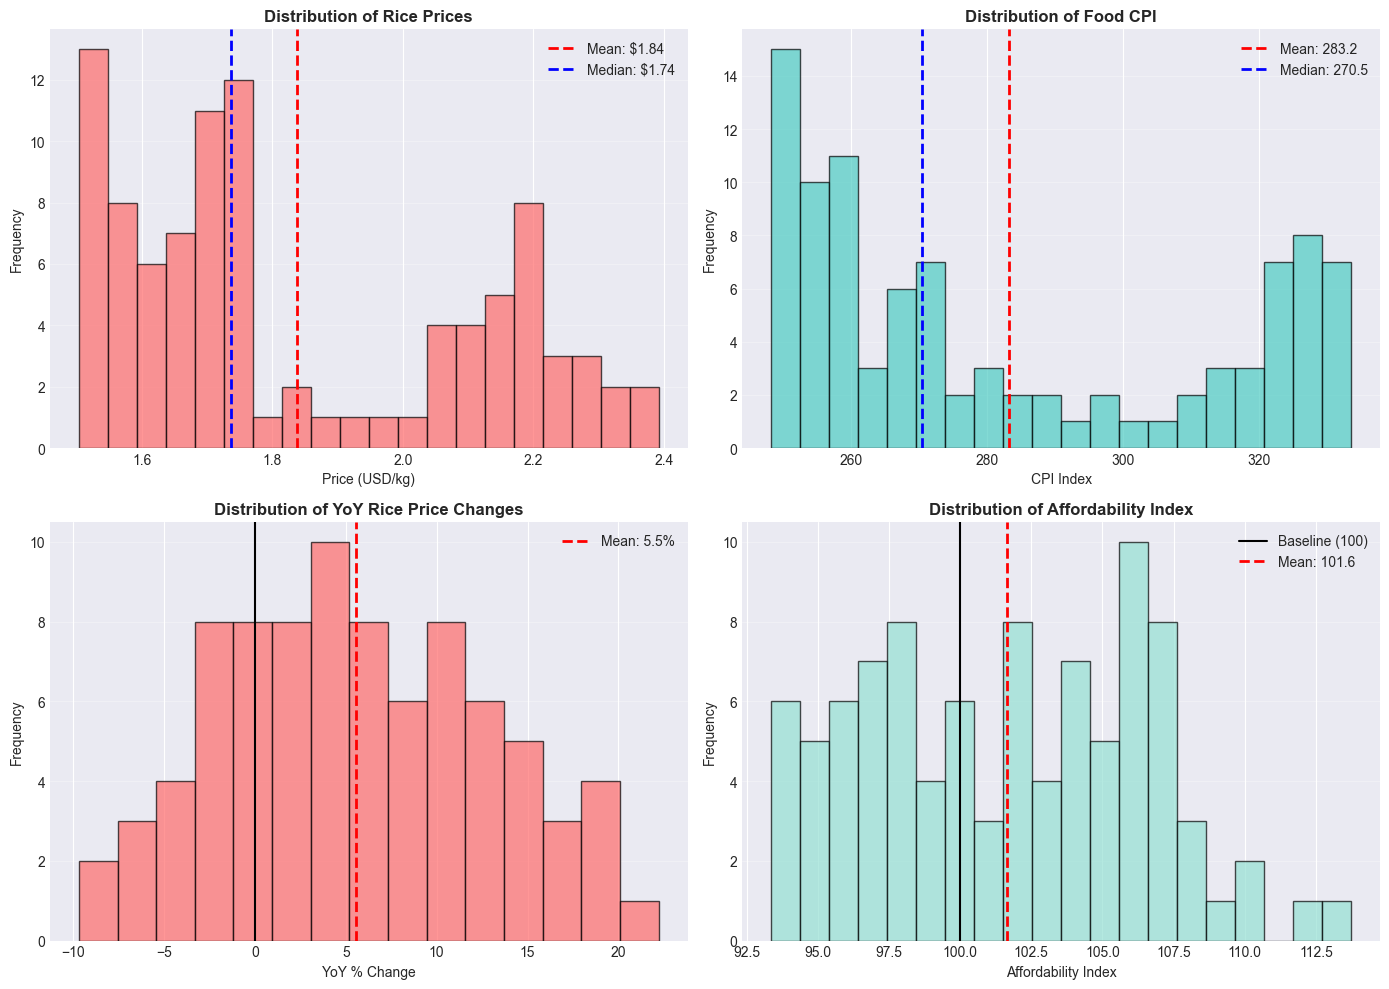

✓ Distribution histograms created


In [33]:
print("="*80)
print("EDA VISUALIZATION 9: DISTRIBUTIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram 1: Rice Prices
axes[0,0].hist(merged_df['price_usd_per_kg'], bins=20, color='#FF6B6B', 
               alpha=0.7, edgecolor='black')
axes[0,0].axvline(merged_df['price_usd_per_kg'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean: ${merged_df["price_usd_per_kg"].mean():.2f}')
axes[0,0].axvline(merged_df['price_usd_per_kg'].median(), color='blue', 
                  linestyle='--', linewidth=2, label=f'Median: ${merged_df["price_usd_per_kg"].median():.2f}')
axes[0,0].set_title('Distribution of Rice Prices', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Price (USD/kg)', fontsize=10)
axes[0,0].set_ylabel('Frequency', fontsize=10)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3, axis='y')

# Histogram 2: Food CPI
axes[0,1].hist(merged_df['food_cpi_index'], bins=20, color='#4ECDC4', 
               alpha=0.7, edgecolor='black')
axes[0,1].axvline(merged_df['food_cpi_index'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean: {merged_df["food_cpi_index"].mean():.1f}')
axes[0,1].axvline(merged_df['food_cpi_index'].median(), color='blue', 
                  linestyle='--', linewidth=2, label=f'Median: {merged_df["food_cpi_index"].median():.1f}')
axes[0,1].set_title('Distribution of Food CPI', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('CPI Index', fontsize=10)
axes[0,1].set_ylabel('Frequency', fontsize=10)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3, axis='y')

# Histogram 3: YoY Rice Price Changes
yoy_data = merged_df['price_yoy_pct'].dropna()
axes[1,0].hist(yoy_data, bins=15, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[1,0].axvline(0, color='black', linestyle='-', linewidth=1.5)
axes[1,0].axvline(yoy_data.mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {yoy_data.mean():.1f}%')
axes[1,0].set_title('Distribution of YoY Rice Price Changes', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('YoY % Change', fontsize=10)
axes[1,0].set_ylabel('Frequency', fontsize=10)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, axis='y')

# Histogram 4: Affordability Index
axes[1,1].hist(merged_df['affordability_index'], bins=20, color='#95E1D3', 
               alpha=0.7, edgecolor='black')
axes[1,1].axvline(100, color='black', linestyle='-', linewidth=1.5, 
                  label='Baseline (100)')
axes[1,1].axvline(merged_df['affordability_index'].mean(), color='red', 
                  linestyle='--', linewidth=2, 
                  label=f'Mean: {merged_df["affordability_index"].mean():.1f}')
axes[1,1].set_title('Distribution of Affordability Index', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Affordability Index', fontsize=10)
axes[1,1].set_ylabel('Frequency', fontsize=10)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('USA_Rice_CPI_Distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution histograms created")
